# Idea
load model(s) and test them

# Imports

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error, r2_score
from pathlib import Path
from utils.data_loader import find_repo_root
from utils.modeling import aggregate_multistep_predictions
import joblib
import re

# Settings

In [2]:
sampling_rate = '5min'  # available: '20s', '1min', '5min'
start_time = '2024-07-24 00:00:00'
end_time = '2024-12-31 12:59:00'
columns =['orbital_decay', 'trend', '|avg B|', 'F10.7 (LASP)']
target = 'trend'
m = 15

# Load Data

In [3]:
DATA_DIR = find_repo_root() / Path("Dataset/modeling/")
DATA_file = DATA_DIR / Path(f"GFOC_modeling_{sampling_rate}.parquet")
GFOC_data = pd.read_parquet(DATA_file, columns=columns)
# filter by time range
GFOC_data = GFOC_data.loc[start_time:end_time]
print(f"✅ Successfully loaded data with shape: {GFOC_data.shape}")
# column names
print("Column names in the dataset:")
print(GFOC_data.columns.tolist())
print("Sample rate:", pd.infer_freq(GFOC_data.index))

X_file = DATA_DIR / Path(f"X_{sampling_rate}.parquet")
X_test = pd.read_parquet(X_file)
X_test = X_test.loc[start_time:end_time]
y_file = DATA_DIR / Path(f"y_{target}_{sampling_rate}.parquet")
y_test = pd.read_parquet(y_file)
y_test = y_test.loc[start_time:end_time]
print(f"✅ Successfully loaded features X_test with shape: {X_test.shape} and target y_test with shape: {y_test.shape}")

✅ Successfully loaded data with shape: (46236, 4)
Column names in the dataset:
['orbital_decay', 'trend', '|avg B|', 'F10.7 (LASP)']
Sample rate: 5min
✅ Successfully loaded features X_test with shape: (46224, 538) and target y_test with shape: (46224, 48)


# Load Models

In [4]:
MODEL_DIR = find_repo_root() / Path("Analysis/modeling/saved_models")

# load all models with joblib
model_types = ['MultiTaskLassoCV', 'lasso']
models = {}
scalers = {}

# example for loading one model and scaler
model = joblib.load(MODEL_DIR / 'MultiTaskLassoCV_trend_model_1.pkl')
scaler = joblib.load(MODEL_DIR / 'MultiTaskLassoCV_trend_scaler_1.pkl')

# regex to parse filenames
pattern = re.compile(
    r'(?P<model_type>.+?)_(?P<target>.+?)_(?P<kind>model|scaler)_(?P<number>\d+)\.pkl'
)

for pkl_file in MODEL_DIR.glob("*.pkl"):
    match = pattern.match(pkl_file.name)
    if not match:
        continue

    model_type = match.group("model_type")
    target = match.group("target")
    kind = match.group("kind")
    number = int(match.group("number"))

    if model_type not in model_types:
        continue

    # nested structure: models[model_type][target][number]
    if kind == "model":
        models.setdefault(model_type, {}).setdefault(target, {})[number] = (
            joblib.load(pkl_file)
        )

    elif kind == "scaler":
        scalers.setdefault(model_type, {}).setdefault(target, {})[number] = (
            joblib.load(pkl_file)
        )
# check if for each model there is a corresponding scaler
for model_type in models:
    for target in models[model_type]:
        for number in models[model_type][target]:
            assert number in scalers[model_type][target], f"Scaler missing for {model_type} {target} {number}"
print(f"✅ Successfully loaded models and scalers for model types: {list(models.keys())}")

✅ Successfully loaded models and scalers for model types: ['lasso', 'MultiTaskLassoCV']


Show all models

In [5]:
print("Loaded models:\n")

for model_type, targets in models.items():
    print(f"Model type: {model_type}")
    for target, model_nums in targets.items():
        nums = sorted(model_nums.keys())
        print(f"  Target: {target}")
        print(f"    Models: {nums}")
    print()

Loaded models:

Model type: lasso
  Target: trend
    Models: [1, 2, 3]

Model type: MultiTaskLassoCV
  Target: trend
    Models: [1, 2]



# Run Model

In [6]:
predictions = {}

for model_type, targets in models.items():
    for target, model_nums in targets.items():
        for n, model in model_nums.items():

            scaler = scalers[model_type][target][n]

            # scale X_test
            X_test_scaled = pd.DataFrame(
                scaler.transform(X_test),
                index=X_test.index,
                columns=X_test.columns
            )

            # predict
            y_test_pred = pd.DataFrame(
                model.predict(X_test_scaled),
                index=X_test.index,
                columns=y_test.columns
            )

            # store
            predictions.setdefault(model_type, {}) \
                       .setdefault(target, {})[n] = y_test_pred

# Results

## Check Coefficients

In [7]:
coef_df = pd.DataFrame(index=X_test.columns)

for model_type, targets in models.items():
    for target, model_nums in targets.items():
        for number, model in model_nums.items():

            # skip models without coefficients
            if not hasattr(model, "coef_"):
                continue

            coef = model.coef_[1, :] if model.coef_.ndim == 2 else model.coef_

            col_name = f"coeff_{model_type}_{target}_{number}"

            coef_df[col_name] = coef

# reset index to have feature as a column (optional)
coef_df = coef_df.reset_index().rename(columns={"index": "feature"})

# create new dataframe with sorted names
sorted_coef_df = coef_df.copy()
for model_type, targets in models.items():
    for target, model_nums in targets.items():
        for number, model in model_nums.items():

            # skip models without coefficients
            if not hasattr(model, "coef_"):
                continue

            col_name = f"coeff_{model_type}_{target}_{number}"
            temp = coef_df.sort_values(by=col_name, key=abs, ascending=False)

            sorted_coef_df[col_name] = temp['feature'].values
# remove 'feature' column for sorting
features = sorted_coef_df.pop('feature')

# save to csv
coef_df.to_csv(MODEL_DIR / "model_coefficients_comparison.csv", index=False)
sorted_coef_df.to_csv(MODEL_DIR / "model_coefficients_sorted_comparison.csv", index=False)

Plot

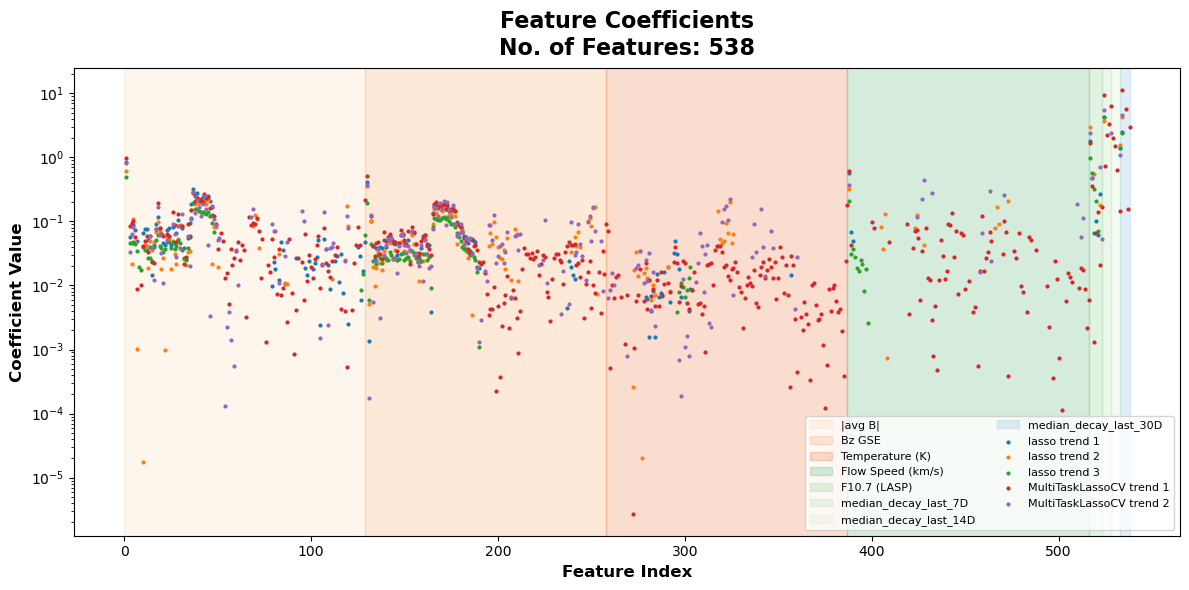

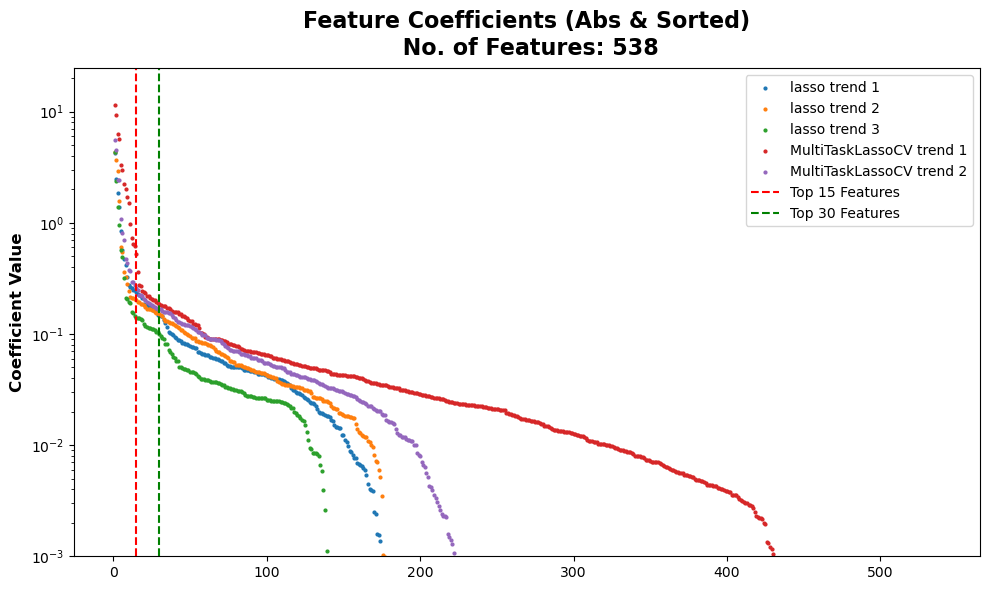

In [ ]:
lag_config_trend = {
    "|avg B|": 129,
    "Bz GSE": 129,
    "Temperature (K)": 129,
    "Flow Speed (km/s)": 129,
    "F10.7 (LASP)": 7,
    "median_decay_last_7D": 5,
    "median_decay_last_14D": 5,
    "median_decay_last_30D": 5,
}

colors = [
    "#fdd0a2", "#fd8d3c", "#e6550d",
    "#31a354", "#74c476", "#a1d99b", "#c7e9c0", "#6baed6"
]

group_positions = {}
start = 0
for i, (feature, length) in enumerate(lag_config_trend.items()):
    end = start + length
    group_positions[feature] = (start, end)
    start = end


fig, ax = plt.subplots(figsize=(12, 6))

# shade backgrounds
for i, (feature, (start, end)) in enumerate(group_positions.items()):
    ax.axvspan(start, end, color=colors[i % len(colors)], alpha=0.2, label=feature)

# plot coefficients
for model_type, targets in models.items():
    for target, model_nums in targets.items():
        for number, model in model_nums.items():

            if not hasattr(model, "coef_"):
                continue

            col_name = f"coeff_{model_type}_{target}_{number}"
            label_name = f"{model_type} {target} {number}"

            ax.scatter(
                range(1, len(coef_df)+1),
                abs(coef_df[col_name]),
                s=4,
                label=label_name
            )

ax.set_ylabel("Coefficient Value")
ax.set_xlabel("Feature Index")
ax.set_title(f"Feature Coefficients\nNo. of Features: {len(coef_df)}")
ax.set_yscale("log")

# handle legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="lower right", fontsize=8, ncol = 2)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
for model_type, targets in models.items():
    for target, model_nums in targets.items():
        for number, model in model_nums.items():

            # skip models without coefficients
            if not hasattr(model, "coef_"):
                continue

            col_name = f"coeff_{model_type}_{target}_{number}"
            label_name = f"{model_type} {target} {number}"
            coefs = abs(coef_df[col_name])
            # sort by size
            coefs_sorted = coefs.sort_values(ascending=False).reset_index(drop=True)

            ax.scatter(range(1,len(coef_df)+1), coefs_sorted, s = 4, label=label_name)
ax.axvline(x=15, color='red', linestyle='--', label='Top 15 Features')
ax.axvline(x=30, color='green', linestyle='--', label='Top 30 Features')
ax.set_ylabel('Coefficient Value')
ax.set_title(f'Feature Coefficients (Abs & Sorted)\n No. of Features: {len(coef_df)}')
ax.set_yscale('log')
ax.set_ylim(bottom=1e-3)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [16]:
dt_seconds = pd.to_timedelta(sampling_rate).total_seconds()
hour = int(60 / (dt_seconds / 60))  # number of samples in one hour
stepsize = 15 

lag_config_trend = {
    # removed having target data as feature to avoid data leakage given the target signal is spread out
    # "orbital_decay": {"lags": list(range(1*hour, 24*hour, 3*hour))}, 
    "|avg B|": {'lags': list(range(1, 3*hour, max(hour//10, 1))) + list(range(3*hour, 50*hour, max(hour//2, 1)))},
    "Bz GSE": {'lags': list(range(1, 3*hour, max(hour//10, 1))) + list(range(3*hour, 50*hour, max(hour//2, 1)))},
    "Temperature (K)": {'lags': list(range(1, 3*hour, max(hour//10, 1))) + list(range(3*hour, 50*hour, max(hour//2, 1)))},
    "Flow Speed (km/s": {'lags': list(range(1, 3*hour, max(hour//10, 1))) + list(range(3*hour, 50*hour, max(hour//2, 1)))},
    "F10.7 (LASP)": {'lags': list(range(1, 24*hour, 6*hour)) + list(range(24*hour, 50*hour, 12*hour))},
    "median_decay_last_7D": {'lags': list(range(1, 50*hour, 12*hour))},
    "median_decay_last_14D": {'lags': list(range(1, 50*hour, 12*hour))},
    "median_decay_last_30D": {'lags': list(range(1, 50*hour, 12*hour))}
}

# create a plot for each feature group
print(lag_config_trend["median_decay_last_7D"]['lags'])

[1, 145, 289, 433, 577]


## Check alphas

The model has the attribute 'alphas_'.
Chosen alpha: 0.01701254279852589
        alpha  mean_cv_mse
36   0.017013    33.519463
35   0.020309    33.521721
37   0.014251    33.522978
38   0.011938    33.530312
34   0.024245    33.535309
39   0.010000    33.540339
33   0.028943    33.572470
24   0.142510    33.577533
25   0.119378    33.583177
32   0.034551    33.622737
23   0.170125    33.622905
26   0.100000    33.623495
31   0.041246    33.639857
30   0.049239    33.641862
29   0.058780    33.650486
27   0.083768    33.661024
28   0.070170    33.663026
22   0.203092    33.723748
21   0.242446    33.877558
20   0.289427    34.110644
19   0.345511    34.449946
18   0.412463    34.761491
17   0.492388    34.944553
16   0.587802    35.142758
15   0.701704    35.426669
14   0.837678    35.845964
13   1.000000    36.453881
12   1.193777    37.324556
11   1.425103    38.422188
10   1.701254    39.720841
9    2.030918    41.232741
8    2.424462    42.771343
7    2.894266    44.234203
6    3.45

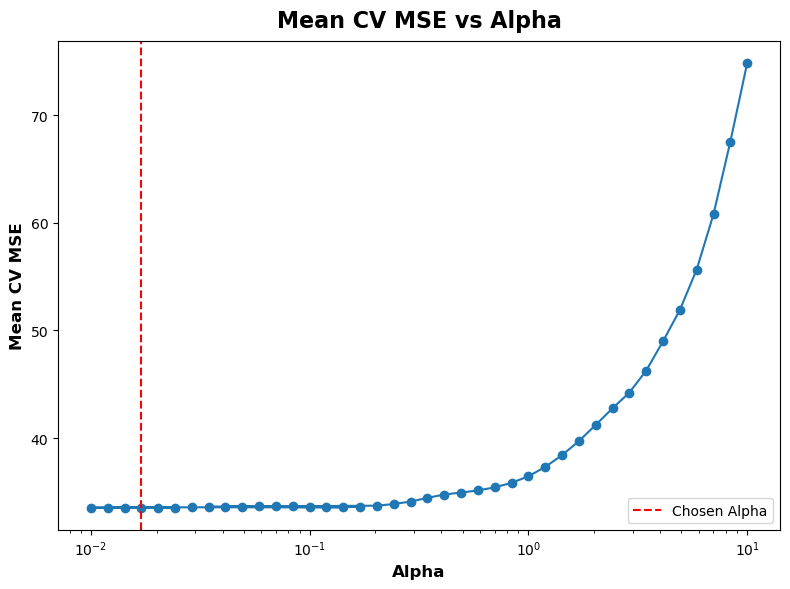

In [15]:
# check if model has an attribute alphas_
if not hasattr(model, 'alphas_'):
   print("The loaded model does not have the attribute 'alphas_'.")
else:
    print("The model has the attribute 'alphas_'.")
    best_alpha = model.alpha_
    print("Chosen alpha:", best_alpha)
    
# check if model has an attribute mse_path_
if not hasattr(model, 'mse_path_'):
   print("The loaded model does not have the attribute 'mse_path_'.")
else:
    alpha_mse_df = pd.DataFrame({
        "alpha": model.alphas_,
        "mean_cv_mse": model.mse_path_.mean(axis=1)
    }).sort_values("mean_cv_mse", ascending=True)
    print(alpha_mse_df)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(alpha_mse_df['alpha'], alpha_mse_df['mean_cv_mse'], marker='o')
    ax.set_xscale('log')
    ax.set_xlabel('Alpha')
    ax.set_ylabel('Mean CV MSE')
    ax.set_title('Mean CV MSE vs Alpha')
    ax.axvline(best_alpha, color='red', linestyle='--', label='Chosen Alpha')
    ax.legend()
    plt.show()

## Check Test Error

Test RMSE: 6.61
Test R2: 0.762


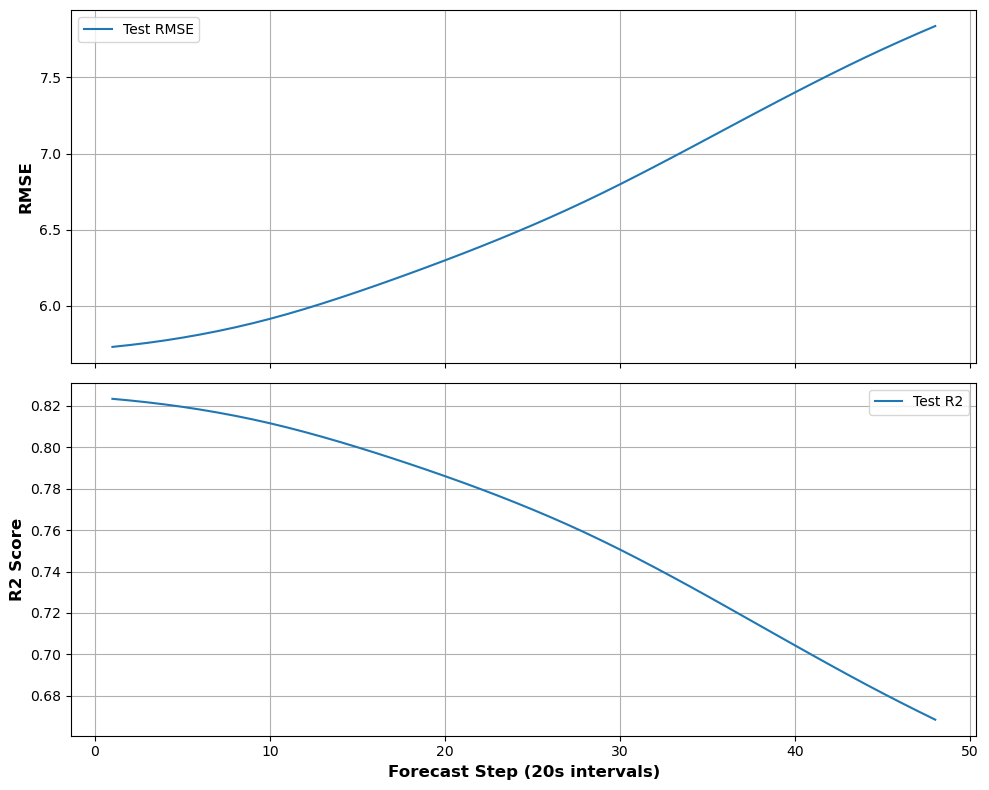

In [8]:
test_rmse = root_mean_squared_error(y_test, y_test_pred)
print((f"Test RMSE: {test_rmse:.3}"))
test_r2 = r2_score(y_test, y_test_pred)
print((f"Test R2: {test_r2:.3}"))

test_rmse_list = []
test_r2_list = []

for i in range(len(y_test.columns)):
    test_rmse_list.append(root_mean_squared_error(y_test.iloc[:, i], y_test_pred.iloc[:, i]))
    test_r2_list.append(r2_score(y_test.iloc[:, i], y_test_pred.iloc[:, i]))
fix, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
xtest = [int(col.split('_')[-1]) for col in y_test.iloc[0].index]
ax[0].plot(xtest,test_rmse_list, label='Test RMSE')
ax[0].set_ylabel('RMSE')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(xtest, test_r2_list, label='Test R2')
ax[1].set_ylabel('R2 Score')
ax[1].set_xlabel('Forecast Step (20s intervals)')
ax[1].legend()
ax[1].grid(True)
plt.tight_layout()
plt.show()

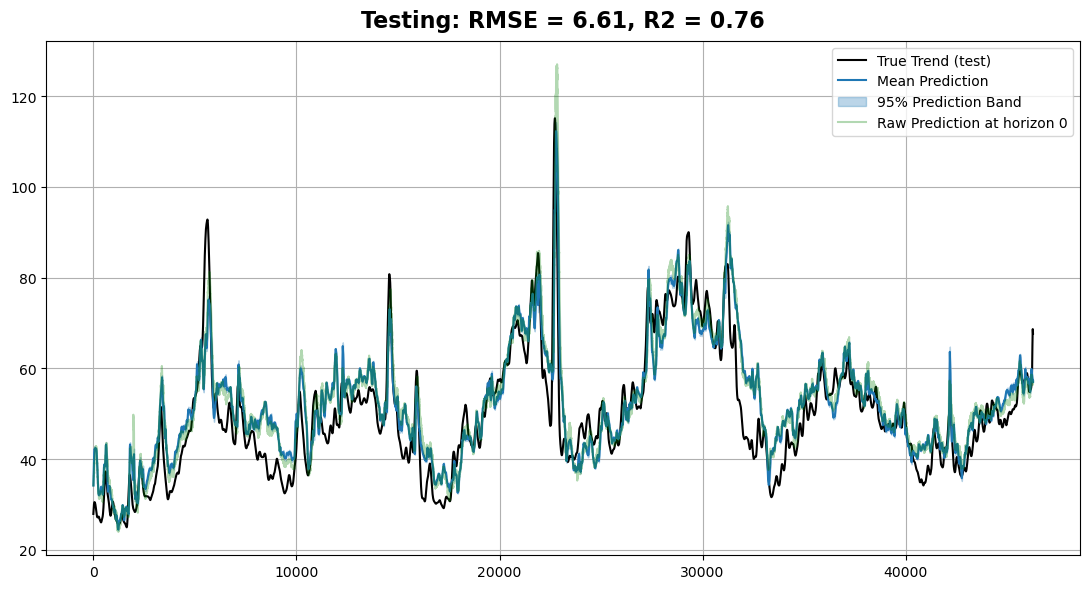

In [ ]:
od_test = aggregate_multistep_predictions(y_test, dt_seconds=dt_seconds, error_kind='sem')
od_test_pred = aggregate_multistep_predictions(y_test_pred, dt_seconds=dt_seconds, error_kind='sem')

fig, ax = plt.subplots(1, 1, figsize=(11, 6))
test_range = range(len(od_test))
# plot complete forecast horizon
ax.plot(test_range, od_test['mean'], color='black')
ax.plot(test_range, od_test_pred['mean'], color='C0')
ax.fill_between(test_range, od_test_pred['mean'] - 1.96 *od_test_pred['sem'], od_test_pred['mean'] + 1.96 *od_test_pred['sem'], color='C0', alpha=0.3)
ax.plot(test_range, od_test_pred['horizon0'], color='green',  alpha=0.3)
_ = ax.legend(['True Trend (test)', 'Mean Prediction', '95% Prediction Band', 'Raw Prediction at horizon 0'])
ax.grid(True)
ax.set_title(f"Testing: RMSE = {root_mean_squared_error(y_test, y_test_pred):.2f}, R2 = {r2_score(y_test, y_test_pred):.2f}")
plt.tight_layout()
plt.show()

### Plot subsets

In [10]:
# split into subsets
NO_subsets = 10
splits = np.array_split(od_test.index, NO_subsets)
test_subsets = []
test_pred_subsets = []
for idx_chunk in splits:
    test_subsets.append(od_test.loc[idx_chunk])
    test_pred_subsets.append(od_test_pred.loc[idx_chunk])

In [11]:
def plot_subsets(true_subsets, pred_subsets, title_prefix):
    rows = len(true_subsets)
    i = 0
    fig, axes = plt.subplots(rows, 1, figsize=(11, 3*rows))

    if rows == 1:
        axes = [axes]

    for ax, df_true, df_pred in zip(axes, true_subsets, pred_subsets):
        ax.plot(df_true.index, df_true['mean'], color='black')
        ax.plot(df_pred.index, df_pred['mean'], color='C0')
        ax.fill_between(df_pred.index,
                        df_pred['mean'] - 1.96 * df_pred['sem'],
                        df_pred['mean'] + 1.96 * df_pred['sem'],
                        color='C0', alpha=0.3)
        ax.plot(df_pred.index, df_pred['horizon0'], color='green', alpha=0.3)

        ax.legend(['True Trend', 'Mean Prediction', '95% Prediction Band', 'Raw Prediction (horizon 0)'])
        ax.grid(True)

        subset_start = df_true.index.min().strftime('%Y-%m-%d %H:%M:%S')
        ax.set_title(f"{title_prefix} subset {i}, starting {subset_start}")
        i += 1

    plt.tight_layout()
    plt.show()


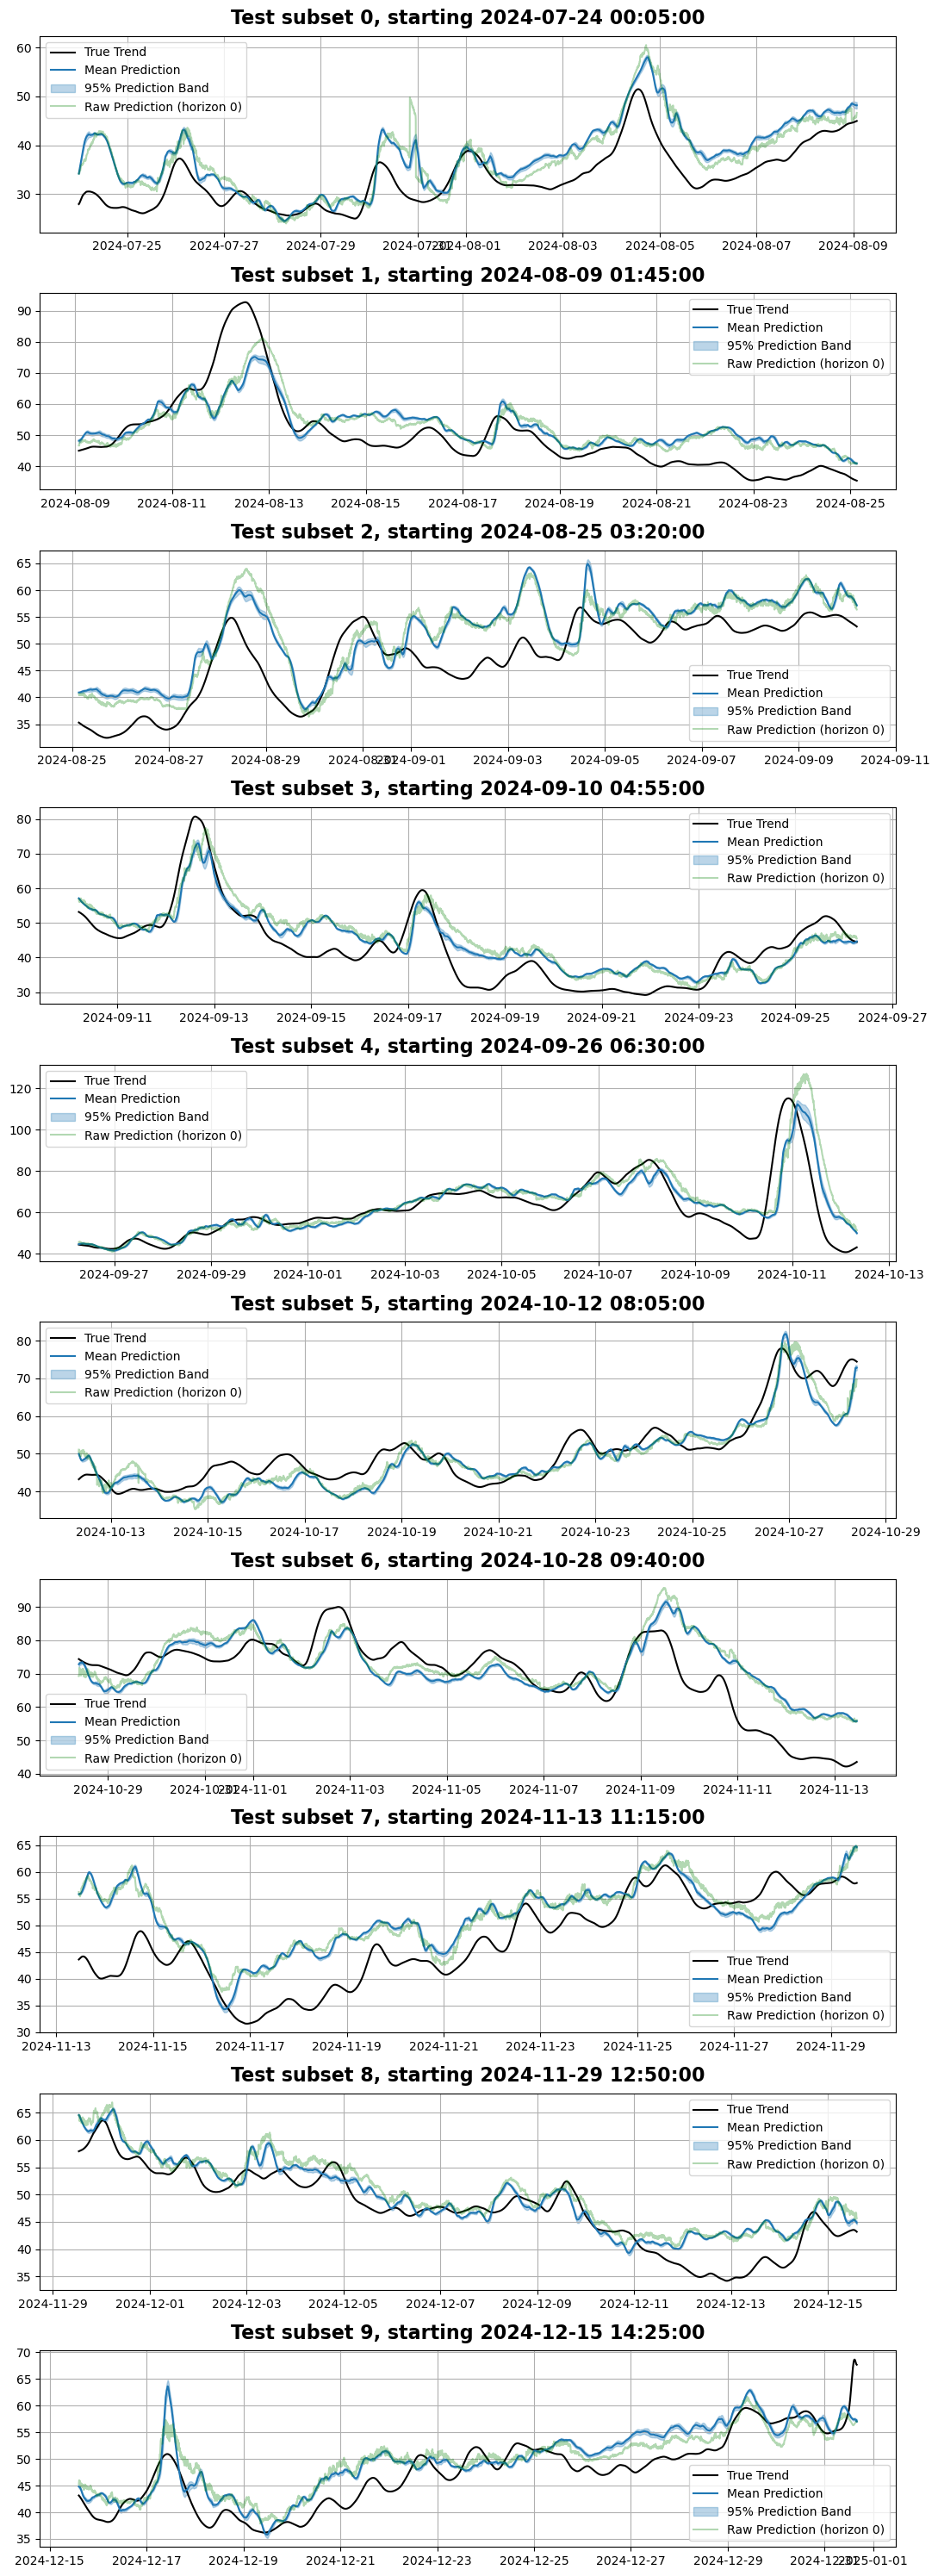

In [12]:
plot_subsets(test_subsets, test_pred_subsets, "Test")

## Plot single forecasts

In [13]:
def plot_forecast_for_event(event_id, time):
    idx = y_test.index.get_loc(time)
    time_idx = y_test.index[idx]

    # Extract sample
    sample_test = X_test.iloc[idx]
    sample_test_F = sample_test.filter(like='F10.7')
    sample_test_B = sample_test.filter(like='|avg B|')
    # sample_test_y = y_test.iloc[idx]

    # Compute lag times
    lag_times_F = [-int(col.split('_')[-1]) * dt_seconds / 60 for col in sample_test_F.index]
    lag_times_B = [-int(col.split('_')[-1]) * dt_seconds / 60 for col in sample_test_B.index]
    # lag_times_y = [int(col.split('_')[-1]) * dt_seconds / 60 for col in sample_test_y.index]

    sample_test_F.index = lag_times_F
    sample_test_B.index = lag_times_B

    # Define time window for decay plotting
    time_window = (time_idx - pd.Timedelta(hours=24), time_idx + pd.Timedelta(hours=24))
    true_decay = GFOC_data.loc[time_window[0]:time_window[1], target]
    pred_trend = y_test_pred.iloc[idx]
    bz_window = GFOC_data.loc[time_window[0]:time_window[1], '|avg B|']

    fig, ax = plt.subplots(figsize=(10, 6), nrows=2)
    ax = ax.flatten()

    # Plot lagged features
    ax[0].scatter(sample_test_F.index, sample_test_F.values, color='blue')
    ax2 = ax[0].twinx()
    ax2.scatter(sample_test_B.index, sample_test_B.values, color='orange', alpha=0.7)

    ax[0].set_title(f'Input lags for F10.7 and |avg B| for event id {event_id}\n{y_test.iloc[idx].name}')
    ax[0].set_xlabel('Lagged Features')
    ax[0].set_ylabel('F10.7 Value', color='blue')
    ax2.set_ylabel('|avg B| Value', color='orange')
    ax[0].grid(True)

    xticks = ax[0].get_xticks()
    ax[0].set_xticklabels([f'{int(t/60)}h' for t in xticks])

    # Plot decay trends
    ax[1].plot(true_decay.index, true_decay.values, label=f'True {target}', color='black')
    pred_times = [time_idx + pd.Timedelta(minutes=m * (i + 1)) for i in range(len(pred_trend))]
    ax[1].plot(pred_times, pred_trend.values, marker='.', linestyle='None', color='red', label=f'Predicted {target}')

    ax[1].set_title(f'Predicted {target} vs. True {target}')
    ax[1].set_xlabel('Time')
    ax[1].set_ylabel('Decay Rate (m/day)')
    ax[1].legend()
    ax[1].grid(True)

    # Overlay |avg B| on second plot
    ax2 = ax[1].twinx()
    ax2.scatter(bz_window.index, bz_window.values, color='blue', alpha=0.8, s=1)
    ax2.set_ylabel('|avg B|', color='blue')

    # Mark forecast horizon start time
    ax[1].axvline(time_idx, color='gray', linestyle='--', label='Forecast Horizon Start Time')

    plt.tight_layout()
    plt.show()

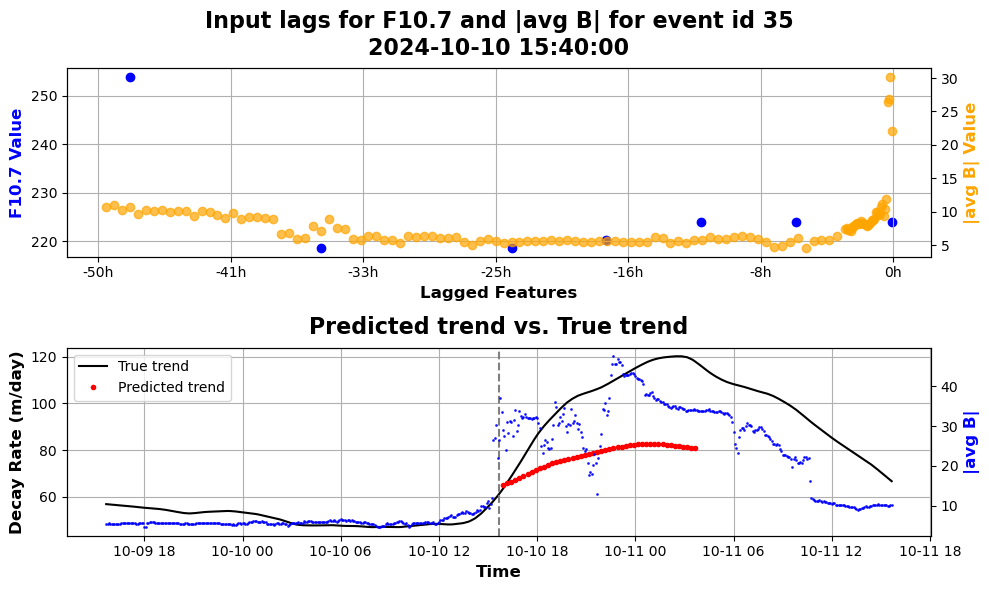

In [14]:
event_id = 35
event_time = '2024-10-10 15:40:00'
plot_forecast_for_event(event_id, event_time)